# Stitching 
Trying to do this in python? 
Uses the `stitching` package
Code from https://github.com/OpenStitching/stitching_tutorial/blob/master/Stitching%20Tutorial.ipynb

In [6]:
from matplotlib import pyplot as plt
import cv2 as cv
import numpy as np
from wellstitching import *
from pathlib import Path

from PIL import Image
import numpy as np

def load_grayscale_16bit_image(image_path):
    """
    Load a 16-bit grayscale image and return it as a numpy array.
    Args:
        image_path (str or Path): Path to the image file.
    Returns:
        np.ndarray: 2D numpy array of the image.
    """
    with Image.open(image_path) as img:
        # Ensure image is in 16-bit mode
        if img.mode != 'I;16':
            img = img.convert('I;16')
        arr = np.array(img)
    return arr

def grayscale16_to_rgb(image_path):
    # Load 16-bit grayscale image
    with Image.open(image_path) as img:
        arr = np.array(img)
        arr = arr*20
        # Optionally scale to 8-bit for display or compatibility
        arr_8bit = (arr / 256).astype(np.uint8)
        # Stack to make RGB
        rgb_arr = np.stack([arr_8bit]*3, axis=-1)
        rgb_img = Image.fromarray(rgb_arr, mode='RGB')
    return np.asarray(rgb_img)

# Usage:
# rgb_image = grayscale16_to_rgb('your_image.tif')
# rgb_image.save('converted_image.png')


def plot_image(img, figsize_in_inches=(5,5)):
    fig, ax = plt.subplots(figsize=figsize_in_inches)
    ax.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.show()
    
def plot_images(imgs, figsize_in_inches=(15, 10), ncols=5):
    n_imgs = len(imgs)
    nrows = (n_imgs + ncols - 1) // ncols
    fig, axs = plt.subplots(nrows, ncols, figsize=figsize_in_inches)
    axs = axs.flatten()
    for i, img in enumerate(imgs):
        axs[i].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        axs[i].axis('off')
    # Hide any unused subplots
    for j in range(i + 1, len(axs)):
        axs[j].axis('off')
    plt.tight_layout()
    plt.show()

def get_image_paths(img_set):
    return [str(path) for path in img_set]

In [7]:
input_folder = "/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250328_rep05"
output_base = "/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250328_rep05"
field_pattern = r"f(\d{2})"  # Matches "FXX" where XX are digits
block_a_numbers = [1] + list(range(22, 41))
file_list = load_sorted_directory_list(input_folder)
nchannels = get_nchannels(file_list)
grouped_files_by_channel = group_files_by_channel(file_list, nchannels)

grouped_files_by_well = group_files_by_well(file_list, 40, nchannels)
#print_grouped_files(grouped_files_by_well)
block_a_files, block_b_files = get_well_stitching_block_paths(grouped_files_by_well)


In [8]:
from stitching import Stitcher
from stitching.images import Images
import cv2 as cv

def stitch_image_block(file_list, output_path, save = False):
    """Stitches a list of images and saves the result."""
    print(f"Stitching {len(file_list)} images to {output_path}...")
    stitcher = Stitcher()#detector="sift", confidence_threshold=0.2)  # Add your settings here
    panorama = stitcher.stitch(file_list)
    
    plot_image(panorama)
    # Save the image using a library like OpenCV
    if save:
        cv.imwrite(output_path, panorama)



['/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250328_rep05/MAX_ch2-r02c05f02.tif', '/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250328_rep05/MAX_ch2-r02c05f03.tif', '/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250328_rep05/MAX_ch2-r02c05f04.tif', '/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250328_rep05/MAX_ch2-r02c05f05.tif', '/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250328_rep05/MAX_ch2-r02c05f06.tif', '/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250328_rep05/MAX_ch2-r02c05f07.tif', '/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250328_rep05/MAX_ch2-r02c05f08.tif', '/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250328_rep05/MAX_ch2-r02c05f09.tif', '/mnt/bigdisk1/AllieSpa

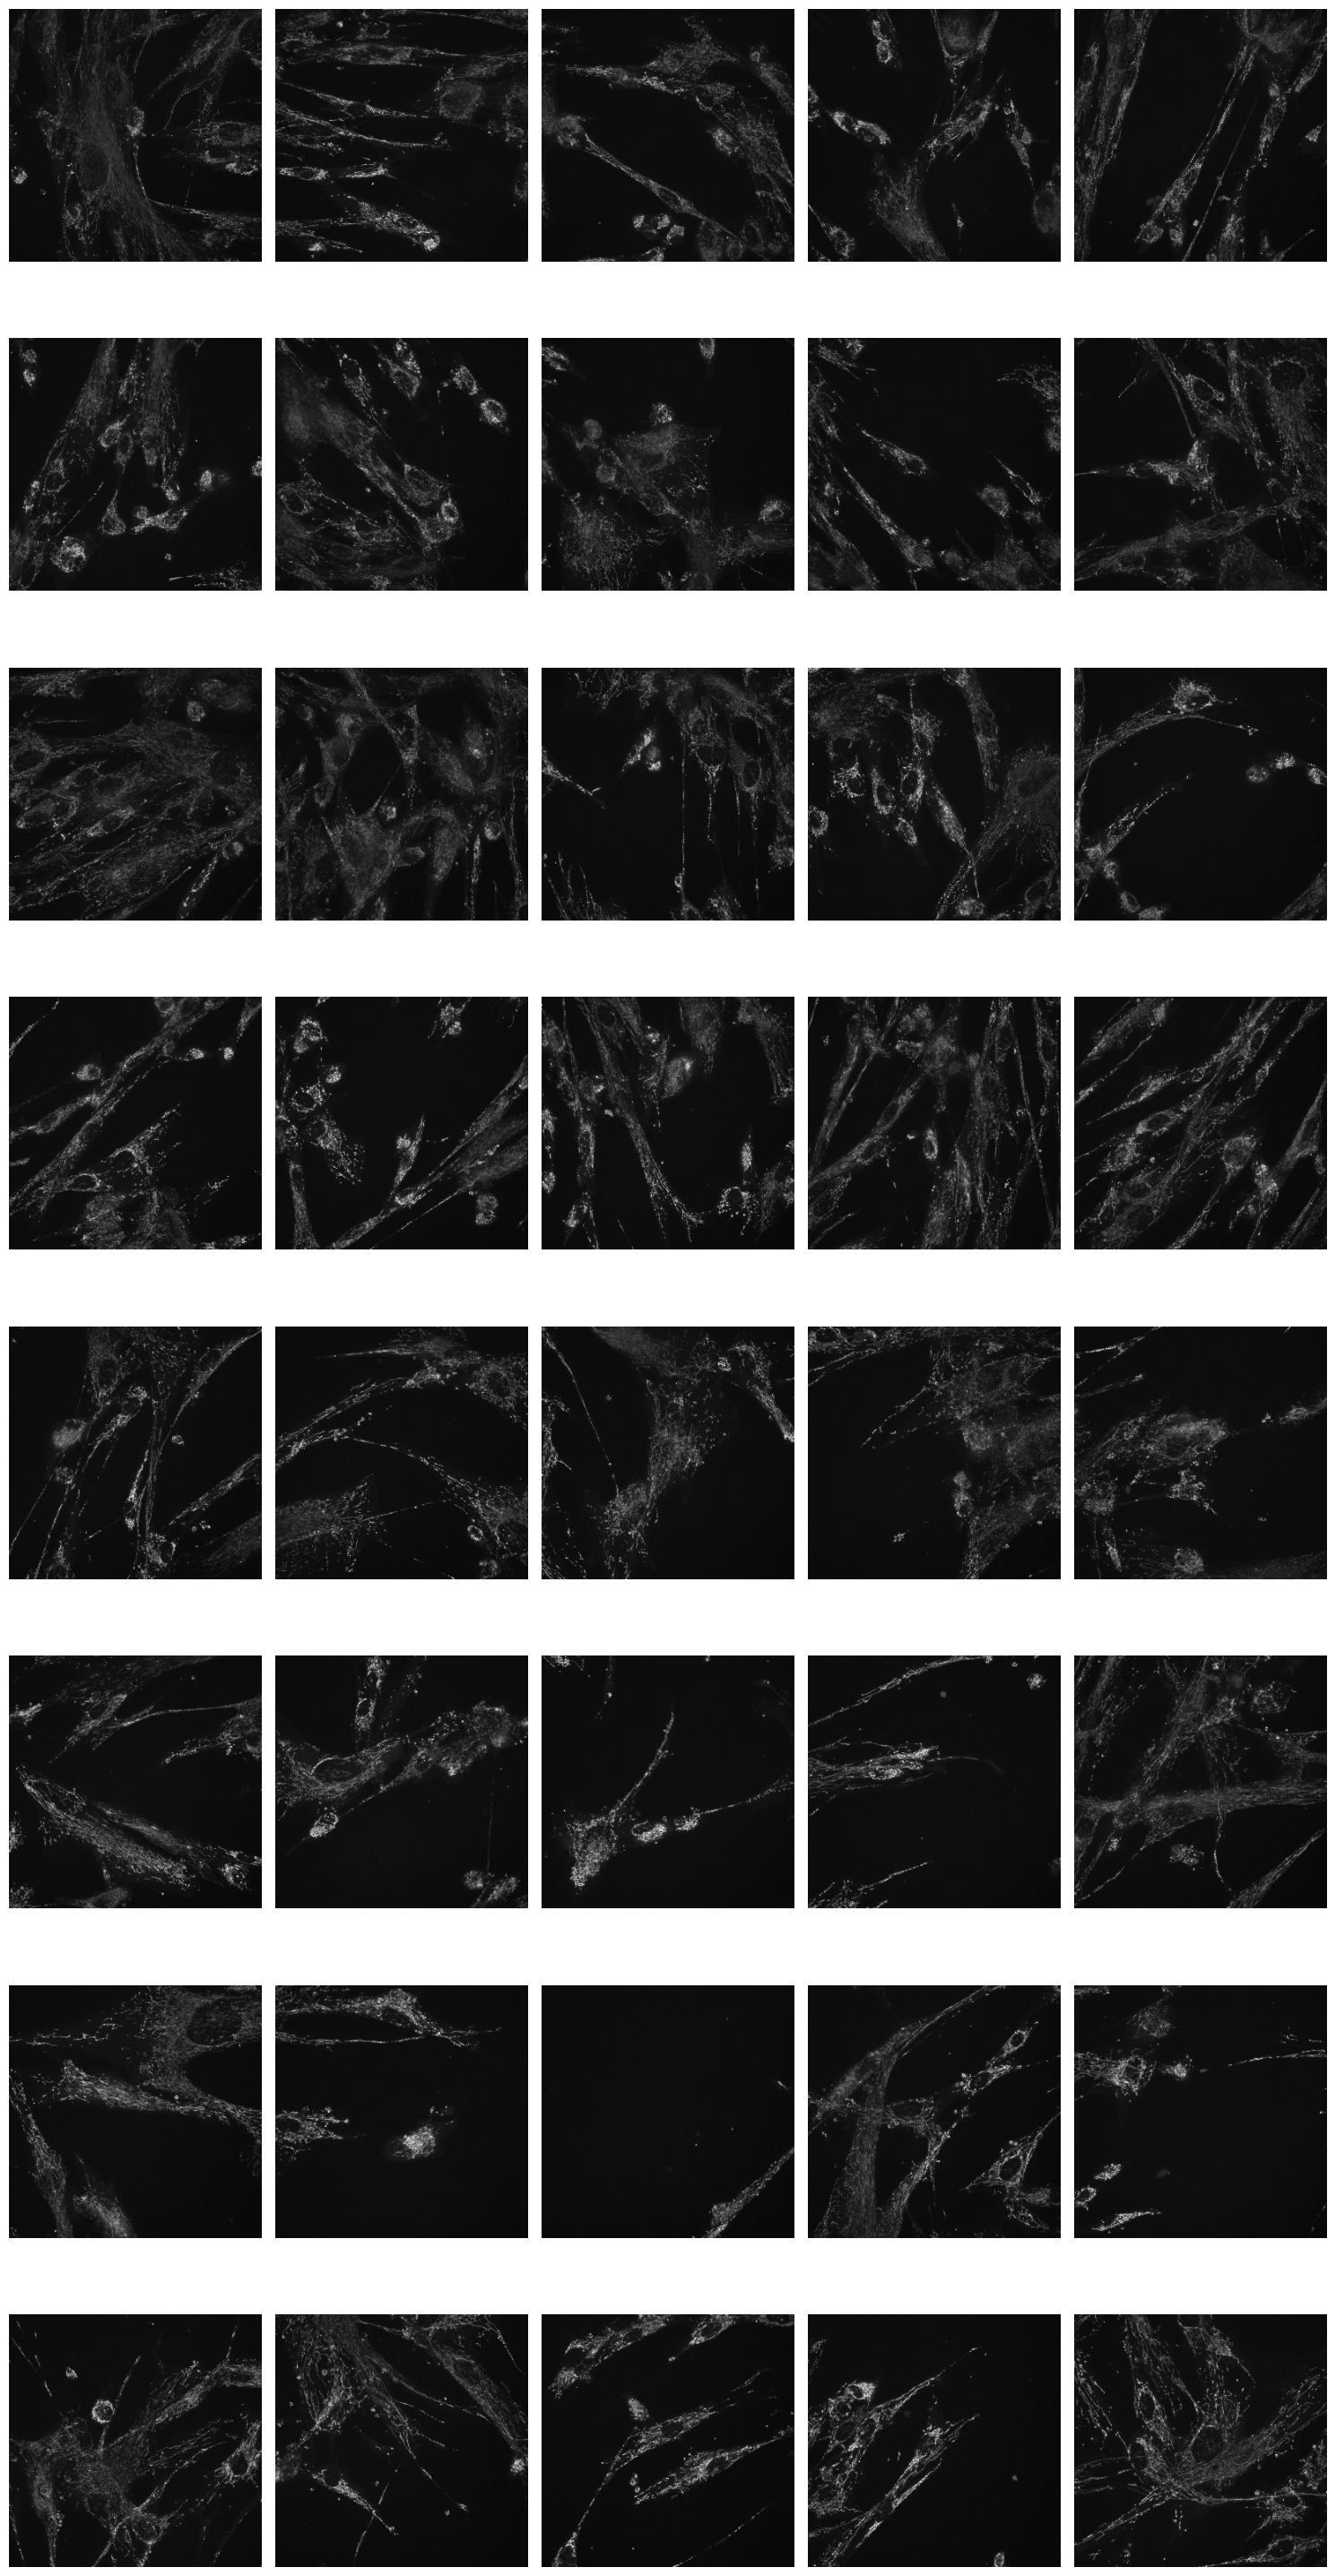

In [9]:
block_b_by_well = group_files_by_well(block_b_files)
test_well = block_b_by_well[2]
test_well_ch2 = [file for file in test_well if "ch2-" in str(file)]

output_folder_test = os.path.join(output_base,"test_stitching")
os.makedirs(output_folder_test, exist_ok=True)

paths = get_image_paths(test_well_ch2)
print(paths)
images = []
for img in paths:
    #load images with pillow
    loaded_img = grayscale16_to_rgb(img)
    images.append(loaded_img)
    #plot_image(loaded_img)
images = Images.of(images)

medium_imgs = list(images.resize(Images.Resolution.MEDIUM))
low_imgs = list(images.resize(Images.Resolution.LOW))
final_imgs = list(images.resize(Images.Resolution.FINAL))

plot_images(low_imgs, (15,30))


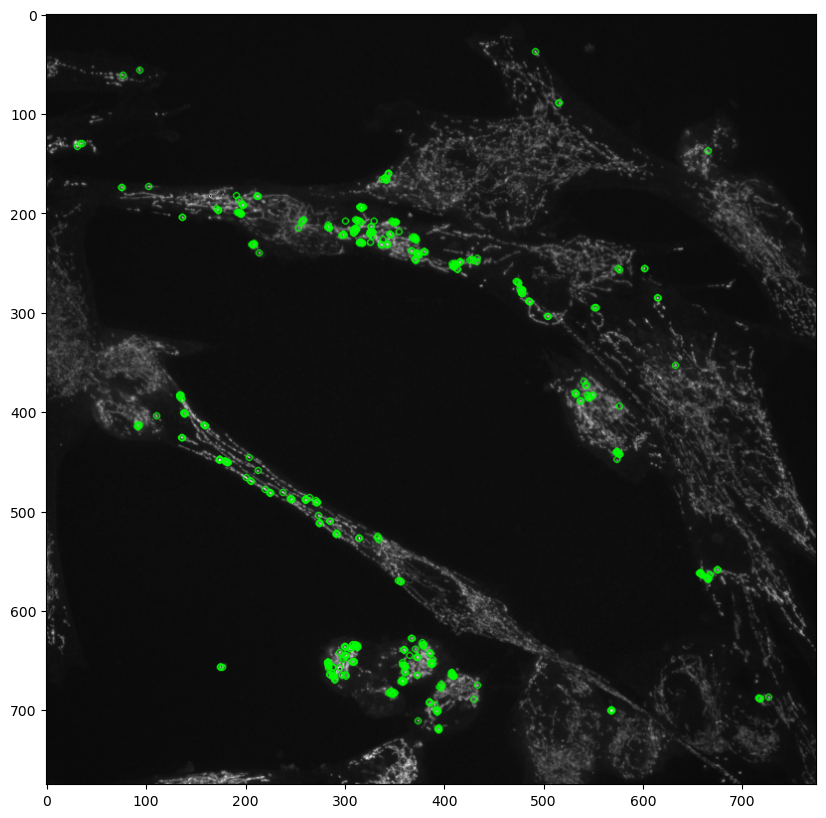

In [10]:
from stitching.feature_detector import FeatureDetector

finder = FeatureDetector()
features = [finder.detect_features(img) for img in medium_imgs]
keypoints_center_img = finder.draw_keypoints(medium_imgs[2], features[2])
plot_image(keypoints_center_img, (15,10))

{'estimator': 'affine', 'wave_correct_kind': 'no', 'matcher_type': 'affine', 'adjuster': 'affine', 'warper_type': 'affine', 'compensator': 'no'}


/opt/miniconda3/envs/stitching/lib/python3.13/site-packages/stitching/subsetter.py:32: StitchingWarning: Not all images are included in the final panorama. If this is not intended, use the 'matches_graph_dot_file' parameter to analyze your matches. You might want to lower the 'confidence_threshold' or try another 'detector' to include all your images.
  warnings.warn(


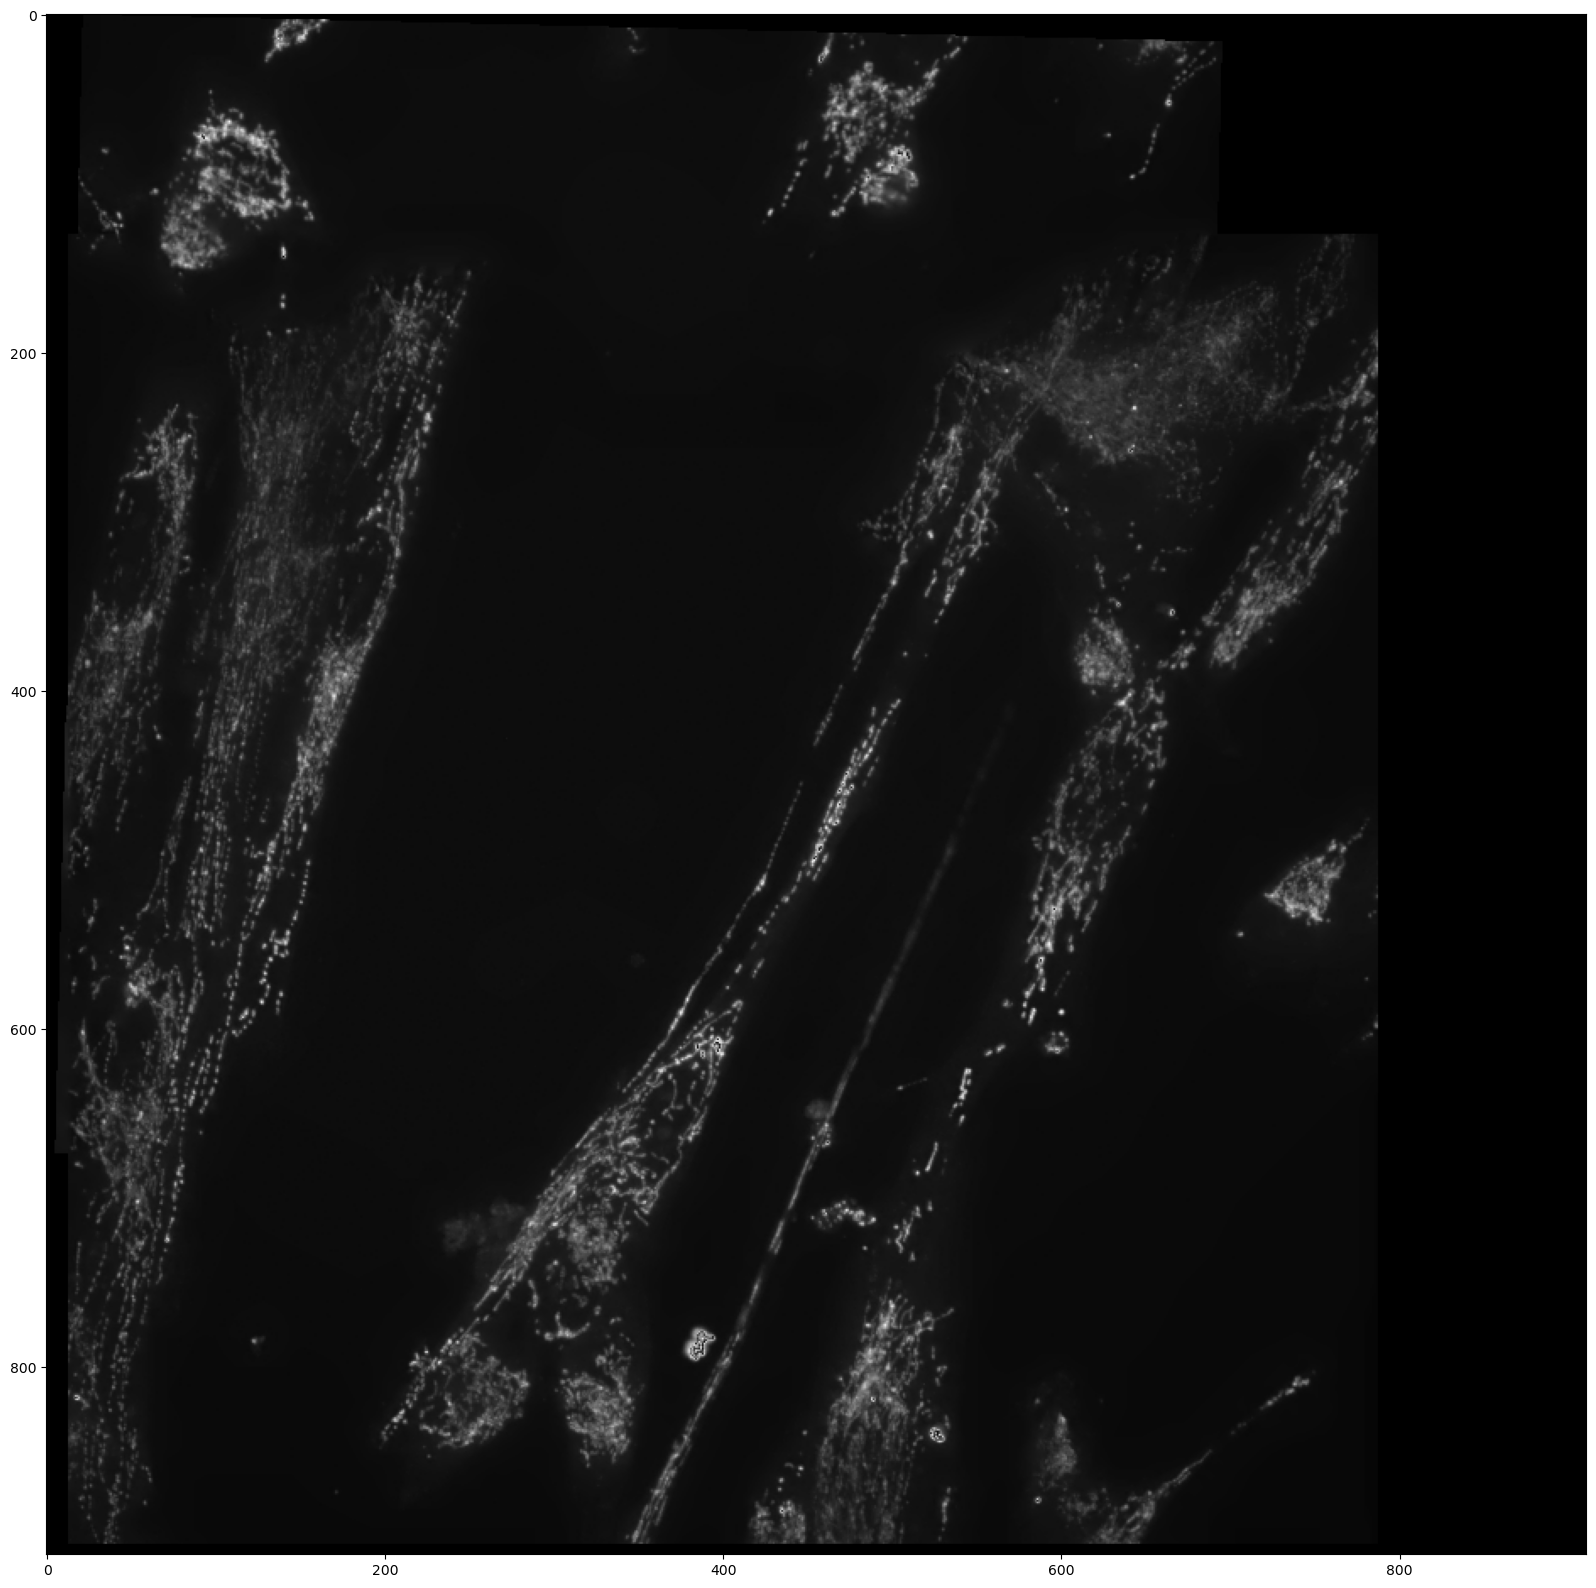

In [11]:
from stitching import AffineStitcher

print(AffineStitcher.AFFINE_DEFAULTS)
settings = {# The whole plan should be considered
            "crop": False,
            # The matches confidences aren't that good
            "confidence_threshold": 0.4}    

stitcher = AffineStitcher(**settings)
panorama = stitcher.stitch(medium_imgs[4:])

plot_image(panorama, (20,20))
# Comparison:
# print(Stitcher.DEFAULT_SETTINGS)
# print(AffineStitcher.DEFAULT_SETTINGS)

In [12]:
stitcher = Stitcher(detector="sift", confidence_threshold=0.2)#detector="sift", confidence_threshold=0.2)  # Add your settings here
panorama = stitcher.stitch(low_imgs)
plot_image(panorama, (20,20))
#stitch_image_block(images,output_folder_test, save = False)

StitchingError: No match exceeds the given confidence threshold. Do your images have enough overlap and common features? If yes, you might want to lower the 'confidence_threshold' or try another 'detector'.